
# EDA Feature Engineering Notebook
## Repeat Claimer by Disease x Hospital Country (Non-ML)

Notebook ini khusus untuk **analisis data calon fitur** (belum modeling ML), dengan fokus:

1. Polis yang punya pola klaim berulang per penyakit (`ICD_Group`).
2. Pola lokasi/negara rumah sakit dari pasien repeat.
3. Perbedaan biaya antar negara untuk penyakit berulang.
4. Sinyal bulanan berbasis history (untuk dipakai sebagai fitur forecasting berikutnya).

Output utama notebook akan diekspor ke folder `feature_analysis_outputs/`.


In [1]:

import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 80)

BASE_DIR = Path.cwd()
DATA_PATH = BASE_DIR / 'dataset' / 'Data_Klaim_Enriched.csv'
OUT_DIR = BASE_DIR / 'feature_analysis_outputs'
OUT_DIR.mkdir(parents=True, exist_ok=True)

print('DATA_PATH:', DATA_PATH)
print('OUT_DIR:', OUT_DIR)


DATA_PATH: /home/data/kuliah/EDA/mcfitb/dataset/Data_Klaim_Enriched.csv
OUT_DIR: /home/data/kuliah/EDA/mcfitb/feature_analysis_outputs


## 1) Load and Clean Data

In [2]:

def normalize_country(x):
    if pd.isna(x):
        return 'Unknown'
    s = str(x).strip().lower()
    if s == 'indonesia':
        return 'Indonesia'
    if 'singapore' in s:
        return 'Singapore'
    if 'malaysia' in s:
        return 'Malaysia'
    if s in {'overseas', 'others', 'other'}:
        return 'Other_Overseas'
    return 'Other_Overseas'


def load_claims(path):
    df = pd.read_csv(path)
    df = df.drop_duplicates(
        subset=['Nomor Polis', 'Tanggal Pasien Masuk RS', 'Nominal Klaim Yang Disetujui'],
        keep='first'
    )

    # Parse tanggal utama
    df['Tanggal Masuk'] = pd.to_datetime(df['Tanggal Pasien Masuk RS'], errors='coerce')
    df['Tanggal Bayar'] = pd.to_datetime(df['Tanggal Pembayaran Klaim'], errors='coerce')
    df['visit_date'] = df['Tanggal Masuk'].fillna(df['Tanggal Bayar'])

    # Drop yang tidak punya tanggal kunjungan
    df = df.dropna(subset=['visit_date']).copy()

    # Standarisasi variabel inti
    df['ICD_Group'] = df['ICD_Group'].fillna('Unknown')
    df['country_group'] = df['Lokasi RS'].apply(normalize_country)
    df['Bulan'] = df['visit_date'].dt.to_period('M').dt.to_timestamp(how='start')

    # Pastikan numerik
    df['Nominal Klaim Yang Disetujui'] = pd.to_numeric(df['Nominal Klaim Yang Disetujui'], errors='coerce').fillna(0.0)

    # Keep relevant columns
    keep_cols = [
        'Claim ID', 'Nomor Polis', 'Plan Code', 'Gender', 'Usia',
        'visit_date', 'Bulan', 'ICD_Group', 'country_group',
        'Nominal Klaim Yang Disetujui'
    ]
    df = df[keep_cols].copy()
    return df


claims = load_claims(DATA_PATH)

print('Rows:', len(claims))
print('Unique polis:', claims['Nomor Polis'].nunique())
print('Date range:', claims['visit_date'].min().date(), 'to', claims['visit_date'].max().date())

display(claims.head())


Rows: 4617
Unique polis: 1210
Date range: 2024-01-01 to 2025-07-31


,Claim ID,Nomor Polis,Plan Code,Gender,Usia,visit_date,Bulan,ICD_Group,country_group,Nominal Klaim Yang Disetujui
0,C-0001-M,POL-0176,M-001,F,57,2024-05-27,2024-05-01,Neoplasma/Kanker,Singapore,28093653.0
1,C-0002-M,POL-3288,M-002,M,67,2024-07-15,2024-07-01,Neoplasma/Kanker,Malaysia,80987278.0
2,C-0003-M,POL-1786,M-002,F,64,2024-05-16,2024-05-01,Neoplasma/Kanker,Singapore,183047130.0
3,C-0004-M,POL-1786,M-002,F,64,2024-07-18,2024-07-01,Neoplasma/Kanker,Singapore,191424386.0
4,C-0005-M,POL-2778,M-002,F,55,2024-06-06,2024-06-01,Neoplasma/Kanker,Singapore,138936357.0


## 2) Quick Portfolio Snapshot

,metric,value
0,total_claim_rows,4617.000000
1,unique_polis,1210.000000
2,unique_icd_group,18.000000
3,pct_indonesia,0.670565
4,pct_singapore,0.220056
5,pct_malaysia,0.098549
6,pct_other_overseas,0.009313


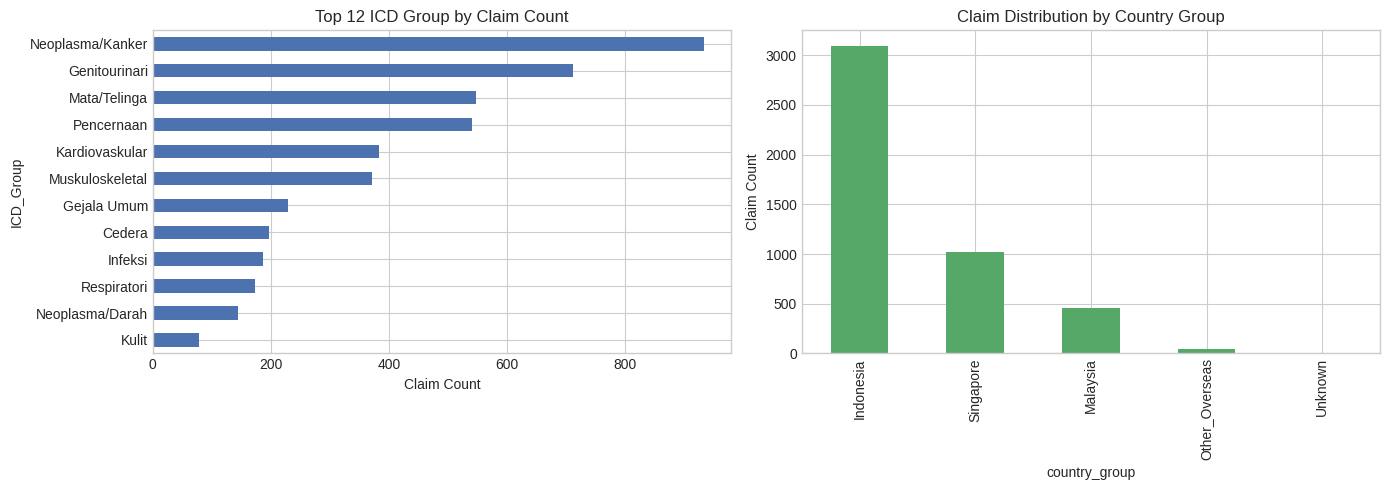

In [3]:

summary = pd.DataFrame({
    'metric': [
        'total_claim_rows',
        'unique_polis',
        'unique_icd_group',
        'pct_indonesia',
        'pct_singapore',
        'pct_malaysia',
        'pct_other_overseas'
    ],
    'value': [
        len(claims),
        claims['Nomor Polis'].nunique(),
        claims['ICD_Group'].nunique(),
        (claims['country_group'] == 'Indonesia').mean(),
        (claims['country_group'] == 'Singapore').mean(),
        (claims['country_group'] == 'Malaysia').mean(),
        (claims['country_group'] == 'Other_Overseas').mean(),
    ]
})

display(summary)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

claims['ICD_Group'].value_counts().head(12).sort_values().plot(kind='barh', ax=axes[0], color='#4C72B0')
axes[0].set_title('Top 12 ICD Group by Claim Count')
axes[0].set_xlabel('Claim Count')

claims['country_group'].value_counts().plot(kind='bar', ax=axes[1], color='#55A868')
axes[1].set_title('Claim Distribution by Country Group')
axes[1].set_ylabel('Claim Count')

plt.tight_layout()
plt.show()


## 3) Build Policy-Disease Repeat Profile

In [4]:

# interval klaim per polis+penyakit
claims_sorted = claims.sort_values(['Nomor Polis', 'ICD_Group', 'visit_date']).copy()
claims_sorted['interval_days'] = (
    claims_sorted.groupby(['Nomor Polis', 'ICD_Group'])['visit_date']
    .diff().dt.days
)


# profil policy-disease
policy_disease = (
    claims_sorted
    .groupby(['Nomor Polis', 'ICD_Group'], as_index=False)
    .agg(
        n_claims=('Claim ID', 'count'),
        total_nominal=('Nominal Klaim Yang Disetujui', 'sum'),
        avg_nominal=('Nominal Klaim Yang Disetujui', 'mean'),
        std_nominal=('Nominal Klaim Yang Disetujui', 'std'),
        first_visit=('visit_date', 'min'),
        last_visit=('visit_date', 'max'),
        active_months=('Bulan', 'nunique'),
        n_countries=('country_group', 'nunique')
    )
)

interval_stats = (
    claims_sorted.dropna(subset=['interval_days'])
    .groupby(['Nomor Polis', 'ICD_Group'], as_index=False)
    .agg(
        n_intervals=('interval_days', 'count'),
        avg_interval_days=('interval_days', 'mean'),
        med_interval_days=('interval_days', 'median'),
        std_interval_days=('interval_days', 'std')
    )
)

country_mix = (
    claims_sorted
    .pivot_table(
        index=['Nomor Polis', 'ICD_Group'],
        columns='country_group',
        values='Claim ID',
        aggfunc='count',
        fill_value=0
    )
    .reset_index()
)

for c in ['Indonesia', 'Singapore', 'Malaysia', 'Other_Overseas', 'Unknown']:
    if c not in country_mix.columns:
        country_mix[c] = 0

country_mix['claims_total_country'] = (
    country_mix[['Indonesia', 'Singapore', 'Malaysia', 'Other_Overseas', 'Unknown']].sum(axis=1)
)

for c in ['Indonesia', 'Singapore', 'Malaysia', 'Other_Overseas', 'Unknown']:
    country_mix[f'share_{c.lower()}'] = country_mix[c] / np.maximum(country_mix['claims_total_country'], 1)

country_cols = ['Indonesia', 'Singapore', 'Malaysia', 'Other_Overseas', 'Unknown']
country_mix['dominant_country'] = country_mix[country_cols].idxmax(axis=1)
country_mix['dominant_country_share'] = (
    country_mix[country_cols].max(axis=1) / np.maximum(country_mix[country_cols].sum(axis=1), 1)
)

policy_disease = (
    policy_disease
    .merge(interval_stats, on=['Nomor Polis', 'ICD_Group'], how='left')
    .merge(
        country_mix[[
            'Nomor Polis', 'ICD_Group',
            'dominant_country', 'dominant_country_share',
            'share_indonesia', 'share_singapore', 'share_malaysia',
            'share_other_overseas', 'share_unknown'
        ]],
        on=['Nomor Polis', 'ICD_Group'],
        how='left'
    )
)

policy_disease['is_repeat'] = (policy_disease['n_claims'] >= 2).astype(int)
policy_disease['claims_per_active_month'] = policy_disease['n_claims'] / np.maximum(policy_disease['active_months'], 1)

display(policy_disease.head(12))

policy_disease.to_csv(OUT_DIR / 'policy_disease_repeat_profile.csv', index=False)
print('saved:', OUT_DIR / 'policy_disease_repeat_profile.csv')


,Nomor Polis,ICD_Group,n_claims,total_nominal,avg_nominal,std_nominal,first_visit,last_visit,active_months,n_countries,n_intervals,avg_interval_days,med_interval_days,std_interval_days,dominant_country,dominant_country_share,share_indonesia,share_singapore,share_malaysia,share_other_overseas,share_unknown,is_repeat,claims_per_active_month
0,POL-0003,Cedera,1,1.413816e+07,1.413816e+07,NaN,2024-09-09,2024-09-09,1,1,NaN,NaN,NaN,NaN,Indonesia,1.0,1.0,0.0,0.0,0.0,0.0,0,1.0
1,POL-0006,Cedera,2,1.786125e+08,8.930625e+07,4.049542e+07,2024-08-16,2024-10-23,2,1,1.0,68.000000,68.0,NaN,Indonesia,1.0,1.0,0.0,0.0,0.0,0.0,1,1.0
2,POL-0010,Pencernaan,2,6.497528e+07,3.248764e+07,4.350671e+07,2024-01-18,2024-01-19,1,1,1.0,1.000000,1.0,NaN,Singapore,1.0,0.0,1.0,0.0,0.0,0.0,1,2.0
3,POL-0011,Pencernaan,2,3.597431e+08,1.798715e+08,1.326352e+08,2024-10-07,2025-06-28,2,2,1.0,264.000000,264.0,NaN,Indonesia,0.5,0.5,0.5,0.0,0.0,0.0,1,1.0
4,POL-0013,Pencernaan,1,1.569392e+08,1.569392e+08,NaN,2025-04-27,2025-04-27,1,1,NaN,NaN,NaN,NaN,Indonesia,1.0,1.0,0.0,0.0,0.0,0.0,0,1.0
5,POL-0018,Kulit,1,3.554081e+06,3.554081e+06,NaN,2024-03-16,2024-03-16,1,1,NaN,NaN,NaN,NaN,Indonesia,1.0,1.0,0.0,0.0,0.0,0.0,0,1.0
6,POL-0020,Kardiovaskular,1,1.836239e+08,1.836239e+08,NaN,2024-07-19,2024-07-19,1,1,NaN,NaN,NaN,NaN,Indonesia,1.0,1.0,0.0,0.0,0.0,0.0,0,1.0
7,POL-0023,Gejala Umum,1,2.268600e+07,2.268600e+07,NaN,2025-03-14,2025-03-14,1,1,NaN,NaN,NaN,NaN,Indonesia,1.0,1.0,0.0,0.0,0.0,0.0,0,1.0
8,POL-0024,Saraf,1,7.618730e+07,7.618730e+07,NaN,2025-02-04,2025-02-04,1,1,NaN,NaN,NaN,NaN,Indonesia,1.0,1.0,0.0,0.0,0.0,0.0,0,1.0
9,POL-0028,Infeksi,1,1.057040e+07,1.057040e+07,NaN,2024-08-05,2024-08-05,1,1,NaN,NaN,NaN,NaN,Indonesia,1.0,1.0,0.0,0.0,0.0,0.0,0,1.0


saved: /home/data/kuliah/EDA/mcfitb/feature_analysis_outputs/policy_disease_repeat_profile.csv


## 4) Disease-Level Repeat Intensity and Country Pattern

Chronic candidate ICD groups: ['Mata/Telinga', 'Neoplasma/Kanker', 'Muskuloskeletal', 'Genitourinari', 'Gejala Umum', 'Neoplasma/Darah']


,ICD_Group,n_policy_disease,n_repeaters,repeat_rate,avg_claims,avg_claims_repeaters,avg_interval_repeaters,avg_nominal
15,Pencernaan,332,146,0.439759,1.629518,2.431507,43.218607,4.424943e+07
10,Mata/Telinga,200,131,0.655000,2.740000,3.656489,28.874512,2.898220e+07
6,Kardiovaskular,227,94,0.414097,1.687225,2.659574,55.474468,9.371610e+07
14,Neoplasma/Kanker,101,86,0.851485,9.237624,10.674419,48.010107,1.296191e+08
12,Muskuloskeletal,179,76,0.424581,2.078212,3.539474,33.586536,1.040686e+08
4,Genitourinari,106,61,0.575472,6.707547,10.918033,26.823305,5.306957e+07
0,Cedera,112,44,0.392857,1.758929,2.931818,36.817587,8.091327e+07
3,Gejala Umum,140,37,0.264286,1.635714,3.405405,48.031907,3.563735e+07
13,Neoplasma/Darah,74,32,0.432432,1.945946,3.187500,28.560268,7.103154e+07
16,Respiratori,117,30,0.256410,1.478632,2.866667,75.097222,5.901601e+07


,ICD_Group,n_policy_disease,n_repeaters,repeat_rate,avg_claims,avg_claims_repeaters,avg_interval_repeaters,avg_nominal
10,Mata/Telinga,200,131,0.655000,2.740000,3.656489,28.874512,2.898220e+07
14,Neoplasma/Kanker,101,86,0.851485,9.237624,10.674419,48.010107,1.296191e+08
12,Muskuloskeletal,179,76,0.424581,2.078212,3.539474,33.586536,1.040686e+08
4,Genitourinari,106,61,0.575472,6.707547,10.918033,26.823305,5.306957e+07
3,Gejala Umum,140,37,0.264286,1.635714,3.405405,48.031907,3.563735e+07
13,Neoplasma/Darah,74,32,0.432432,1.945946,3.187500,28.560268,7.103154e+07


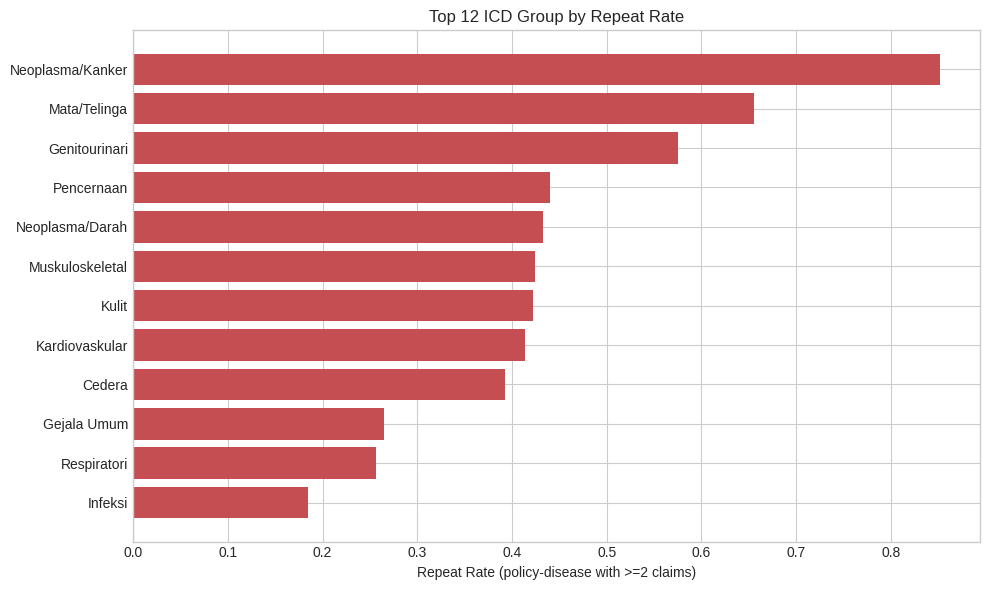

saved: /home/data/kuliah/EDA/mcfitb/feature_analysis_outputs/disease_repeat_profile.csv
saved: /home/data/kuliah/EDA/mcfitb/feature_analysis_outputs/chronic_icd_candidates.csv


In [5]:

disease_profile = (
    policy_disease
    .groupby('ICD_Group', as_index=False)
    .agg(
        n_policy_disease=('Nomor Polis', 'count'),
        n_repeaters=('is_repeat', 'sum'),
        repeat_rate=('is_repeat', 'mean'),
        avg_claims=('n_claims', 'mean'),
        avg_claims_repeaters=('n_claims', lambda x: x[policy_disease.loc[x.index, 'is_repeat'] == 1].mean()),
        avg_interval_repeaters=('avg_interval_days', lambda x: np.nanmean(x)),
        avg_nominal=('avg_nominal', 'mean')
    )
    .sort_values(['n_repeaters', 'avg_claims_repeaters'], ascending=False)
)

# Chronic candidate: repeaters signifikan + intensitas tinggi
chronic_candidates = disease_profile[
    (disease_profile['n_repeaters'] >= 20)
].copy()

if len(chronic_candidates) > 0:
    threshold = chronic_candidates['avg_claims_repeaters'].quantile(0.50)
    chronic_candidates = chronic_candidates[
        chronic_candidates['avg_claims_repeaters'] >= threshold
    ].copy()

chronic_list = chronic_candidates['ICD_Group'].tolist()

print('Chronic candidate ICD groups:', chronic_list)

display(disease_profile.head(20))
display(chronic_candidates)

# Plot
plot_df = disease_profile.head(12).sort_values('repeat_rate')
plt.figure(figsize=(10, 6))
plt.barh(plot_df['ICD_Group'], plot_df['repeat_rate'], color='#C44E52')
plt.title('Top 12 ICD Group by Repeat Rate')
plt.xlabel('Repeat Rate (policy-disease with >=2 claims)')
plt.tight_layout()
plt.show()

disease_profile.to_csv(OUT_DIR / 'disease_repeat_profile.csv', index=False)
pd.DataFrame({'ICD_Group': chronic_list}).to_csv(OUT_DIR / 'chronic_icd_candidates.csv', index=False)
print('saved:', OUT_DIR / 'disease_repeat_profile.csv')
print('saved:', OUT_DIR / 'chronic_icd_candidates.csv')


## 5) Country Cost Multiplier by Disease (Core for Feature Engineering)

,ICD_Group,country_group,n_claims,mean_nominal,median_nominal,p90_nominal,id_median,cost_multiplier_vs_id
7,Gejala Umum,Indonesia,210,2.753010e+07,1.195656e+07,6.010574e+07,11956555.5,1.000000
10,Gejala Umum,Singapore,11,4.097706e+07,2.776923e+07,1.054259e+08,11956555.5,2.322511
8,Gejala Umum,Malaysia,4,1.373145e+07,1.137179e+07,2.835524e+07,11956555.5,0.951093
9,Gejala Umum,Other_Overseas,3,6.385816e+06,2.882730e+05,1.492405e+07,11956555.5,0.024110
11,Gejala Umum,Unknown,1,7.075620e+06,7.075620e+06,7.075620e+06,11956555.5,0.591777
12,Genitourinari,Indonesia,610,1.275728e+07,2.688700e+06,2.291146e+07,2688700.0,1.000000
14,Genitourinari,Singapore,61,8.922587e+07,2.401234e+07,2.450142e+08,2688700.0,8.930838
13,Genitourinari,Malaysia,40,2.525316e+07,1.318311e+07,5.660900e+07,2688700.0,4.903153
30,Mata/Telinga,Indonesia,381,1.326089e+07,8.251961e+06,3.092100e+07,8251961.0,1.000000
33,Mata/Telinga,Singapore,144,6.277814e+07,3.380616e+07,1.455412e+08,8251961.0,4.096742


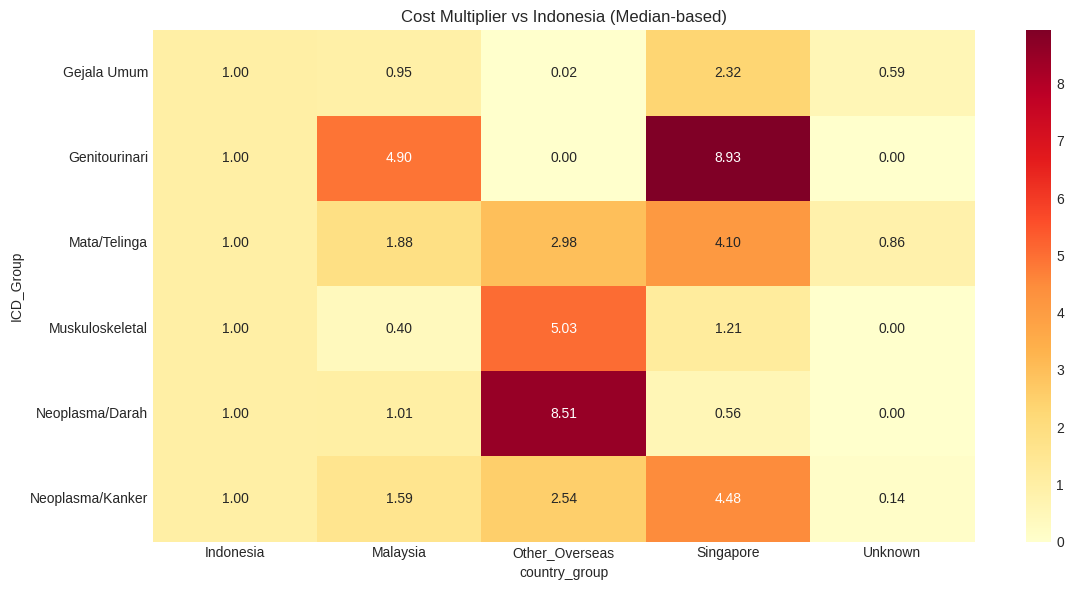

saved: /home/data/kuliah/EDA/mcfitb/feature_analysis_outputs/disease_country_cost_profile.csv


In [6]:

# gunakan median agar robust ke outlier
disease_country = (
    claims
    .groupby(['ICD_Group', 'country_group'], as_index=False)
    .agg(
        n_claims=('Claim ID', 'count'),
        mean_nominal=('Nominal Klaim Yang Disetujui', 'mean'),
        median_nominal=('Nominal Klaim Yang Disetujui', 'median'),
        p90_nominal=('Nominal Klaim Yang Disetujui', lambda x: np.nanpercentile(x, 90))
    )
)

base_id = (
    disease_country[disease_country['country_group'] == 'Indonesia']
    [['ICD_Group', 'median_nominal']]
    .rename(columns={'median_nominal': 'id_median'})
)

disease_country = disease_country.merge(base_id, on='ICD_Group', how='left')
disease_country['cost_multiplier_vs_id'] = disease_country['median_nominal'] / np.maximum(disease_country['id_median'], 1.0)

# fallback multiplier jika tidak ada baseline Indonesia
global_id_median = claims.loc[claims['country_group'] == 'Indonesia', 'Nominal Klaim Yang Disetujui'].median()
disease_country['cost_multiplier_vs_id'] = disease_country['cost_multiplier_vs_id'].replace([np.inf, -np.inf], np.nan)
disease_country['cost_multiplier_vs_id'] = disease_country['cost_multiplier_vs_id'].fillna(
    disease_country['median_nominal'] / max(global_id_median, 1.0)
)

# fokus chronic candidate untuk review cepat
if len(chronic_list) > 0:
    chronic_country = disease_country[disease_country['ICD_Group'].isin(chronic_list)].copy()
else:
    chronic_country = disease_country.copy()

display(chronic_country.sort_values(['ICD_Group', 'n_claims'], ascending=[True, False]).head(30))

plt.figure(figsize=(12, 6))
heat_df = chronic_country.pivot_table(
    index='ICD_Group',
    columns='country_group',
    values='cost_multiplier_vs_id',
    aggfunc='mean'
).fillna(0)

sns.heatmap(heat_df, annot=True, fmt='.2f', cmap='YlOrRd')
plt.title('Cost Multiplier vs Indonesia (Median-based)')
plt.tight_layout()
plt.show()

disease_country.to_csv(OUT_DIR / 'disease_country_cost_profile.csv', index=False)
print('saved:', OUT_DIR / 'disease_country_cost_profile.csv')


## 6) Policy-Level Features for Future ML

In [7]:

# map multiplier per (ICD, country)
mult_map = disease_country.set_index(['ICD_Group', 'country_group'])['cost_multiplier_vs_id'].to_dict()

pd_feat = policy_disease.copy()
pd_feat['is_chronic_candidate'] = pd_feat['ICD_Group'].isin(chronic_list).astype(int)

# multiplier berbasis dominant country pada policy-disease
pd_feat['dom_country_multiplier'] = pd_feat.apply(
    lambda r: mult_map.get((r['ICD_Group'], r['dominant_country']), np.nan), axis=1
)

# score kombinasi intensity x country-cost
pd_feat['repeat_country_risk_score'] = (
    pd_feat['n_claims']
    * pd_feat['dominant_country_share'].fillna(0)
    * pd_feat['dom_country_multiplier'].fillna(1.0)
)

policy_features = (
    pd_feat
    .groupby('Nomor Polis', as_index=False)
    .agg(
        n_icd_profile=('ICD_Group', 'count'),
        n_repeat_disease=('is_repeat', 'sum'),
        n_chronic_disease=('is_chronic_candidate', 'sum'),
        total_claims_all=('n_claims', 'sum'),
        total_nominal_all=('total_nominal', 'sum'),
        avg_repeat_country_risk_score=('repeat_country_risk_score', 'mean'),
        max_repeat_country_risk_score=('repeat_country_risk_score', 'max'),
        mean_dom_country_share=('dominant_country_share', 'mean'),
        mean_share_singapore=('share_singapore', 'mean'),
        mean_share_malaysia=('share_malaysia', 'mean'),
        mean_share_indonesia=('share_indonesia', 'mean')
    )
)

# chronic-focused aggregation
chronic_only = pd_feat[pd_feat['is_chronic_candidate'] == 1].copy()
if len(chronic_only) > 0:
    chronic_policy = (
        chronic_only
        .groupby('Nomor Polis', as_index=False)
        .agg(
            chronic_claims=('n_claims', 'sum'),
            chronic_nominal=('total_nominal', 'sum'),
            chronic_avg_interval_days=('avg_interval_days', 'mean'),
            chronic_risk_score_sum=('repeat_country_risk_score', 'sum')
        )
    )
    policy_features = policy_features.merge(chronic_policy, on='Nomor Polis', how='left')

for c in ['chronic_claims', 'chronic_nominal', 'chronic_avg_interval_days', 'chronic_risk_score_sum']:
    if c in policy_features.columns:
        policy_features[c] = policy_features[c].fillna(0)

policy_features['repeat_intensity'] = policy_features['n_repeat_disease'] / np.maximum(policy_features['n_icd_profile'], 1)

display(policy_features.head(15))

policy_features.to_csv(OUT_DIR / 'policy_repeat_country_features.csv', index=False)
print('saved:', OUT_DIR / 'policy_repeat_country_features.csv')


,Nomor Polis,n_icd_profile,n_repeat_disease,n_chronic_disease,total_claims_all,total_nominal_all,avg_repeat_country_risk_score,max_repeat_country_risk_score,mean_dom_country_share,mean_share_singapore,mean_share_malaysia,mean_share_indonesia,chronic_claims,chronic_nominal,chronic_avg_interval_days,chronic_risk_score_sum,repeat_intensity
0,POL-0003,1,0,0,1,1.413816e+07,1.000000,1.000000,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
1,POL-0006,1,1,0,2,1.786125e+08,2.000000,2.000000,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
2,POL-0010,1,1,0,2,6.497528e+07,4.746309,4.746309,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,POL-0011,1,1,0,2,3.597431e+08,1.000000,1.000000,0.5,0.5,0.0,0.5,0.0,0.0,0.0,0.0,1.0
4,POL-0013,1,0,0,1,1.569392e+08,1.000000,1.000000,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
5,POL-0018,1,0,0,1,3.554081e+06,1.000000,1.000000,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
6,POL-0020,1,0,0,1,1.836239e+08,1.000000,1.000000,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
7,POL-0023,1,0,1,1,2.268600e+07,1.000000,1.000000,1.0,0.0,0.0,1.0,1.0,22686001.0,0.0,1.0,0.0
8,POL-0024,1,0,0,1,7.618730e+07,1.000000,1.000000,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
9,POL-0028,1,0,0,1,1.057040e+07,1.000000,1.000000,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0


saved: /home/data/kuliah/EDA/mcfitb/feature_analysis_outputs/policy_repeat_country_features.csv


## 7) Monthly Historical Signals (Leakage-Safe, For Forecast Features)

,Bulan,claim_count,repeat_claim_share_hist,chronic_claim_share,repeat_and_chronic_share,singapore_share,malaysia_share,country_cost_idx,repeat_country_cost_idx,repeat_claim_share_hist_lag1,chronic_claim_share_lag1,repeat_and_chronic_share_lag1,singapore_share_lag1,malaysia_share_lag1,country_cost_idx_lag1,repeat_country_cost_idx_lag1
0,2024-01-01,300,0.000000,0.550000,0.000000,0.206667,0.076667,2.784287,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2024-02-01,208,0.403846,0.576923,0.326923,0.245192,0.062500,3.575665,3.006981,0.000000,0.550000,0.000000,0.206667,0.076667,2.784287,1.000000
2,2024-03-01,278,0.320144,0.618705,0.276978,0.219424,0.100719,1.986859,1.913617,0.403846,0.576923,0.326923,0.245192,0.062500,3.575665,3.006981
3,2024-04-01,236,0.483051,0.661017,0.415254,0.220339,0.067797,2.295728,2.842662,0.320144,0.618705,0.276978,0.219424,0.100719,1.986859,1.913617
4,2024-05-01,262,0.381679,0.633588,0.347328,0.179389,0.087786,2.054379,3.062165,0.483051,0.661017,0.415254,0.220339,0.067797,2.295728,2.842662
5,2024-06-01,223,0.515695,0.672646,0.457399,0.233184,0.049327,2.704266,3.216890,0.381679,0.633588,0.347328,0.179389,0.087786,2.054379,3.062165
6,2024-07-01,255,0.427451,0.647059,0.368627,0.231373,0.098039,2.689022,2.392742,0.515695,0.672646,0.457399,0.233184,0.049327,2.704266,3.216890
7,2024-08-01,228,0.403509,0.649123,0.342105,0.171053,0.109649,2.118029,2.474591,0.427451,0.647059,0.368627,0.231373,0.098039,2.689022,2.392742
8,2024-09-01,208,0.418269,0.663462,0.370192,0.206731,0.100962,2.443867,1.960113,0.403509,0.649123,0.342105,0.171053,0.109649,2.118029,2.474591
9,2024-10-01,274,0.489051,0.645985,0.397810,0.229927,0.138686,2.157743,2.485045,0.418269,0.663462,0.370192,0.206731,0.100962,2.443867,1.960113


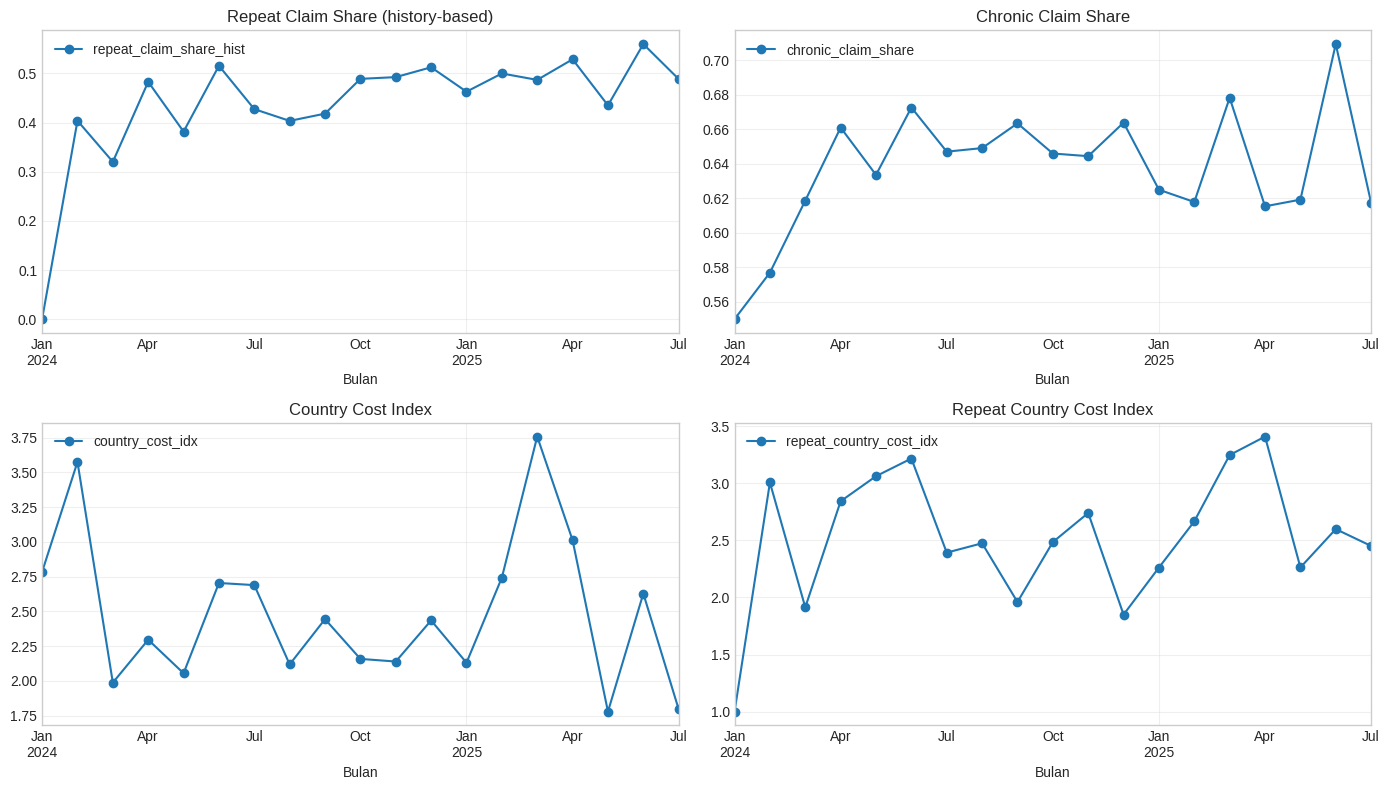

saved: /home/data/kuliah/EDA/mcfitb/feature_analysis_outputs/monthly_repeat_country_signals.csv


In [8]:

# Buat sinyal bulanan dengan history sampai bulan sebelumnya (t-1)
work = claims.sort_values('visit_date').copy()

records = []
history_pairs = set()  # (polis, icd) yang sudah pernah muncul sebelum bulan t

for month in sorted(work['Bulan'].unique()):
    this_month = work[work['Bulan'] == month].copy()

    # flag repeat berdasarkan history sebelumnya
    this_month['pair'] = list(zip(this_month['Nomor Polis'], this_month['ICD_Group']))
    this_month['is_repeat_from_history'] = this_month['pair'].apply(lambda x: 1 if x in history_pairs else 0)
    this_month['is_chronic_candidate'] = this_month['ICD_Group'].isin(chronic_list).astype(int)

    this_month['cost_multiplier'] = this_month.apply(
        lambda r: mult_map.get((r['ICD_Group'], r['country_group']), 1.0), axis=1
    )

    rec = {
        'Bulan': month,
        'claim_count': len(this_month),
        'repeat_claim_share_hist': this_month['is_repeat_from_history'].mean() if len(this_month) else 0,
        'chronic_claim_share': this_month['is_chronic_candidate'].mean() if len(this_month) else 0,
        'repeat_and_chronic_share': (
            ((this_month['is_repeat_from_history'] == 1) & (this_month['is_chronic_candidate'] == 1)).mean()
            if len(this_month) else 0
        ),
        'singapore_share': (this_month['country_group'] == 'Singapore').mean() if len(this_month) else 0,
        'malaysia_share': (this_month['country_group'] == 'Malaysia').mean() if len(this_month) else 0,
        'country_cost_idx': float(np.average(this_month['cost_multiplier'], weights=np.maximum(this_month['Nominal Klaim Yang Disetujui'], 1.0)))
        if len(this_month) else 1.0,
        'repeat_country_cost_idx': float(
            np.average(
                this_month.loc[this_month['is_repeat_from_history'] == 1, 'cost_multiplier'],
                weights=np.maximum(this_month.loc[this_month['is_repeat_from_history'] == 1, 'Nominal Klaim Yang Disetujui'], 1.0)
            )
        ) if (this_month['is_repeat_from_history'] == 1).sum() > 0 else 1.0,
    }
    records.append(rec)

    # update history setelah hitung bulan ini
    history_pairs.update(this_month['pair'].unique().tolist())

monthly_signals = pd.DataFrame(records).sort_values('Bulan').reset_index(drop=True)

# lag signals siap untuk forecasting features (t pakai t-1)
lag_cols = [
    'repeat_claim_share_hist', 'chronic_claim_share', 'repeat_and_chronic_share',
    'singapore_share', 'malaysia_share', 'country_cost_idx', 'repeat_country_cost_idx'
]
for c in lag_cols:
    monthly_signals[f'{c}_lag1'] = monthly_signals[c].shift(1)


display(monthly_signals)

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

monthly_signals.plot(x='Bulan', y='repeat_claim_share_hist', marker='o', ax=axes[0], title='Repeat Claim Share (history-based)')
monthly_signals.plot(x='Bulan', y='chronic_claim_share', marker='o', ax=axes[1], title='Chronic Claim Share')
monthly_signals.plot(x='Bulan', y='country_cost_idx', marker='o', ax=axes[2], title='Country Cost Index')
monthly_signals.plot(x='Bulan', y='repeat_country_cost_idx', marker='o', ax=axes[3], title='Repeat Country Cost Index')

for ax in axes:
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

monthly_signals.to_csv(OUT_DIR / 'monthly_repeat_country_signals.csv', index=False)
print('saved:', OUT_DIR / 'monthly_repeat_country_signals.csv')


## 8) Feature Candidates Summary

In [9]:

feature_candidates = pd.DataFrame([
    {'feature': 'repeat_intensity', 'level': 'policy', 'source': 'policy_repeat_country_features.csv', 'note': 'Proporsi penyakit pada polis yang sudah repeat'},
    {'feature': 'avg_repeat_country_risk_score', 'level': 'policy', 'source': 'policy_repeat_country_features.csv', 'note': 'Skor gabungan frekuensi repeat x dominasi negara x multiplier biaya'},
    {'feature': 'chronic_avg_interval_days', 'level': 'policy', 'source': 'policy_repeat_country_features.csv', 'note': 'Rata-rata jeda antar klaim penyakit chronic'},
    {'feature': 'cost_multiplier_vs_id', 'level': 'disease-country', 'source': 'disease_country_cost_profile.csv', 'note': 'Rasio median biaya disease-country vs Indonesia'},
    {'feature': 'repeat_claim_share_hist_lag1', 'level': 'monthly', 'source': 'monthly_repeat_country_signals.csv', 'note': 'Share klaim bulan lalu yang berasal dari pair polis-penyakit repeat'},
    {'feature': 'repeat_country_cost_idx_lag1', 'level': 'monthly', 'source': 'monthly_repeat_country_signals.csv', 'note': 'Indeks biaya negara untuk klaim repeat bulan lalu'},
    {'feature': 'chronic_claim_share_lag1', 'level': 'monthly', 'source': 'monthly_repeat_country_signals.csv', 'note': 'Share klaim penyakit chronic bulan lalu'},
])

display(feature_candidates)

feature_candidates.to_csv(OUT_DIR / 'feature_candidates_catalog.csv', index=False)
print('saved:', OUT_DIR / 'feature_candidates_catalog.csv')


,feature,level,source,note
0,repeat_intensity,policy,policy_repeat_country_features.csv,Proporsi penyakit pada polis yang sudah repeat
1,avg_repeat_country_risk_score,policy,policy_repeat_country_features.csv,Skor gabungan frekuensi repeat x dominasi nega...
2,chronic_avg_interval_days,policy,policy_repeat_country_features.csv,Rata-rata jeda antar klaim penyakit chronic
3,cost_multiplier_vs_id,disease-country,disease_country_cost_profile.csv,Rasio median biaya disease-country vs Indonesia
4,repeat_claim_share_hist_lag1,monthly,monthly_repeat_country_signals.csv,Share klaim bulan lalu yang berasal dari pair ...
5,repeat_country_cost_idx_lag1,monthly,monthly_repeat_country_signals.csv,Indeks biaya negara untuk klaim repeat bulan lalu
6,chronic_claim_share_lag1,monthly,monthly_repeat_country_signals.csv,Share klaim penyakit chronic bulan lalu


saved: /home/data/kuliah/EDA/mcfitb/feature_analysis_outputs/feature_candidates_catalog.csv
